**SEMINAR 4**

On this occasion, we will retake the Wi-Fi performance prediction problem from
Seminar 1. However, this time you will have to address it using Neural Networks (NNs),
which are much more complex than linear regressions. The dataset that you are going
to use in this seminar (dataset Seminar4.zip) contains Wi-Fi measurements taken
from real residential networks during one month.1 The provided dataset is divided
into train (train data.csv) and test (test data.csv) samples. Both files contain the
following features and labels:


* [Feature] LocationNumber: Represents the zone number where data was collected (up to 35).
* [Feature] RSSI: The signal strength at the given location.
* [Feature] TxLinkSpeed: Transmission link speed (downlink, AP to STA).
* [Feature] RxLinkSpeed: Transmission link speed (uplink, STA to AP).
* [Feature] MainAPConnect: A binary feature that indicates whether the client
is connected to the main AP (1) or an extender (0).
* [Feature] TxThroughput: The actual throughput achieved.
* [Feature] AvgPingLatency: The average latency experienced (measured using
ping tests to a server).

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [3]:
path = '/content/drive/Shared drives/ML4N/seminar 4/'

In [4]:
train_data = pd.read_csv(path + 'train_data.csv')
test_data  = pd.read_csv(path + 'test_data.csv')

PART 1

Your job in this part of the seminar is to visualize and understand the data that you are going to use to train and evaluate your neural network. Complete the following tasks:

1. Describe the statistics behind the main parameters of the dataset. For that, make use of the plots that you consider.

In [5]:
#To know the size of the data
print(train_data.shape)
print(test_data.shape)

##To print the 5 first rows.
print("\nTrain data 5 first rows:")
display(train_data.head())
print("\nTest data 5 first rows:")
display(test_data.head())

# To know mean and standard deviation of the data
print("\ntrain data")
print(train_data.describe().round(2))
print("\ntest data")
print(test_data.describe().round(2))

(33600, 7)
(8400, 7)

Train data 5 first rows:


,LocationNumber,RSSI,TxLinkSpeed,RxLinkSpeed,MainAPConnect,TxThroughput,AvgPingLatency
0,2,-72.32,163.11,118.36,1,13.51,51.79
1,32,-73.18,238.45,212.83,1,3.35,68.80
2,20,-40.67,865.44,863.39,1,17.62,50.79
3,10,-60.66,473.89,396.92,1,14.30,64.15
4,29,-67.96,479.74,355.99,1,4.81,73.81



Test data 5 first rows:


,LocationNumber,RSSI,TxLinkSpeed,RxLinkSpeed,MainAPConnect,TxThroughput,AvgPingLatency
0,16,-53.19,787.51,653.48,1,15.94,56.30
1,24,-62.79,657.90,592.37,1,17.31,49.78
2,34,-71.16,259.18,178.29,0,2.89,55.83
3,28,-63.99,467.56,375.04,1,17.01,85.71
4,6,-69.29,355.26,313.15,1,14.05,59.40



train data
       LocationNumber      RSSI  TxLinkSpeed  RxLinkSpeed  MainAPConnect  \
count        33600.00  33600.00     33600.00     33600.00       33600.00   
mean            18.15    -62.36       491.26       460.95           0.91   
std             10.34      9.44       240.87       251.60           0.28   
min              1.00    -79.04        33.24       -12.53           0.00   
25%              9.00    -70.36       273.20       249.13           1.00   
50%             18.00    -62.91       476.64       396.48           1.00   
75%             27.00    -53.79       664.39       656.42           1.00   
max             36.00    -37.02       905.39       911.00           1.00   

       TxThroughput  AvgPingLatency  
count      33600.00        33600.00  
mean          12.99           54.77  
std            4.41            8.74  
min            0.78           39.30  
25%           11.32           48.94  
50%           14.79           52.29  
75%           15.98           57.47  

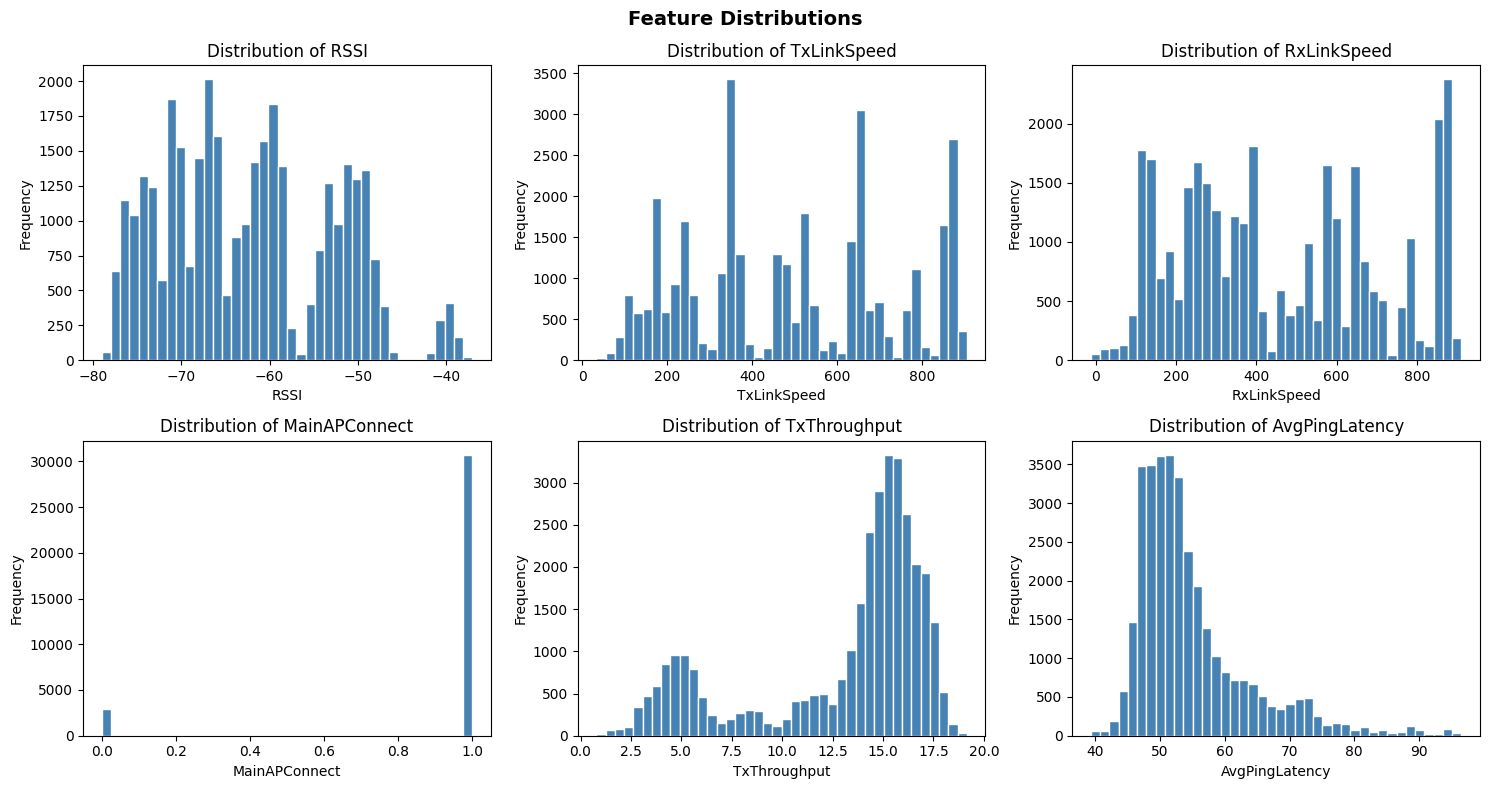

In [6]:
#HISTOGRAM OF THE TRAIN DATA

features = ['RSSI', 'TxLinkSpeed', 'RxLinkSpeed', 'MainAPConnect', 'TxThroughput', 'AvgPingLatency']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(train_data[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

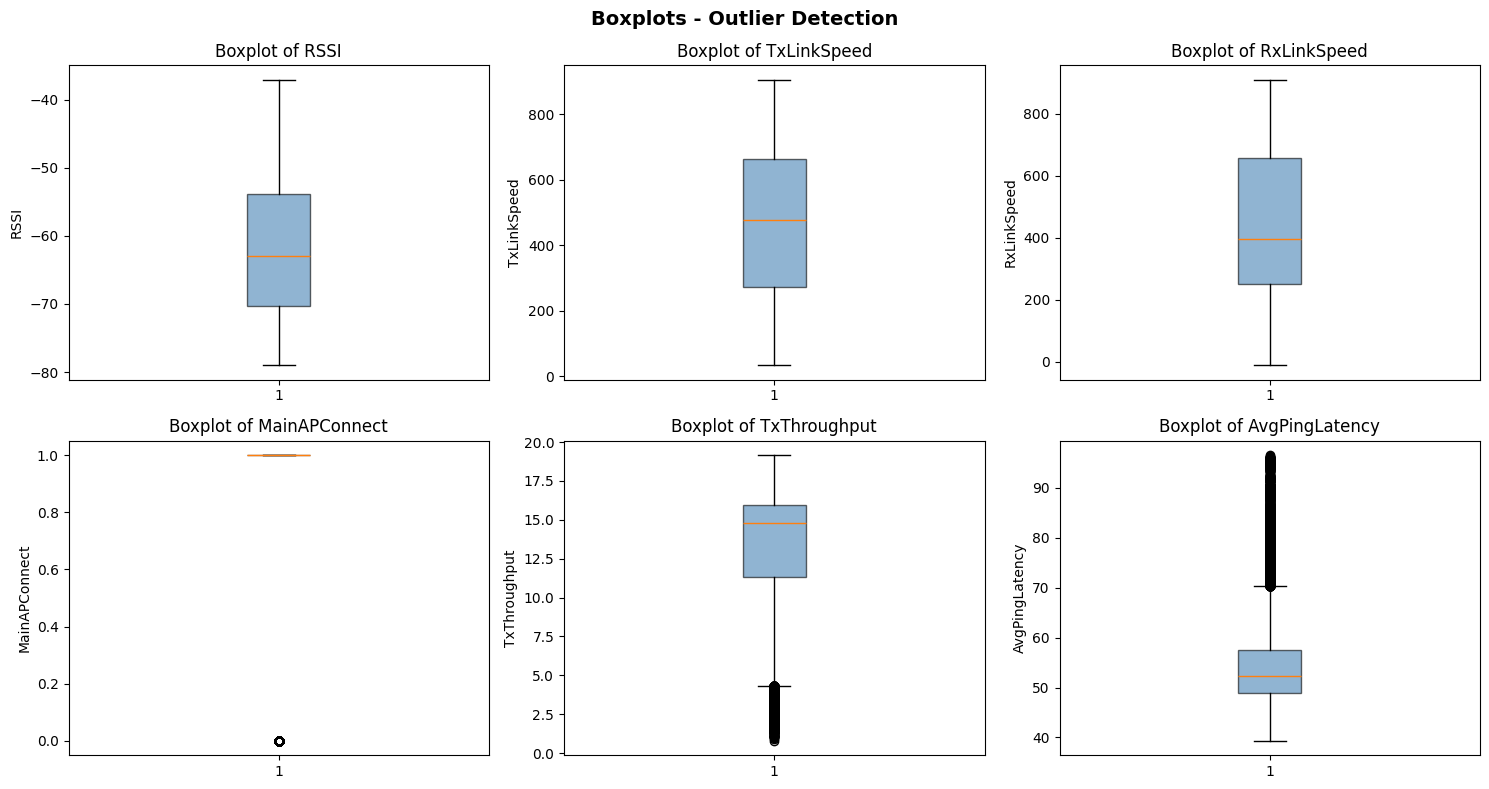

In [7]:
#BOXPLOT OF THE TRAIN DATA

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(train_data[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

plt.suptitle('Boxplots - Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

After analizing the data we can say:

* RSSI: The indicates the intensity of the signal. The mean is -62.36 dBm, and variance 9.57. We think is a week signals in general since normally the RSSI ara -30 dBm to be good. So ours are quite week.

* TxLinkSpeed: Is the speed between the connection from AP to STA. The mean is 491.26 Mbps and variance 242.53. It represents a moderate-to-high link speed. It has a very hight std, meaning the speed connection is very unstable.

* RxLinkSpeed: Is the speed between the connection from STA to AP. The mean is 460.95 Mbps and variance 253.64. We have a bad connection velocity.It has a very hight std, meaning also the speed connection is very unstable.

* MainAPConnect: Is what shows if the user is connected to the main AP or to an extender. The mean 0.91 and variance 0.29. Meaning the bast majority are connected to the main AP meaning the database is imbalanced.

* TxThroughput: Is the actual throughput achieve. The mean is  12.99 Mbps, and the variance 4.44 that it's a good number. It is a very low value compared to the teoretical capacity of the channel.

* AvgPingLatency: is the average latency experienced. The mean is 54.68ms, and the variance 8.75. That is's a decent dealy, not great but aceptable.

2. Perform a correlation analysis between the main features in the dataset and the performance metrics (throughput and delay).

In [8]:
targets = ['TxThroughput', 'AvgPingLatency']
features = ['RSSI', 'TxLinkSpeed', 'RxLinkSpeed', 'MainAPConnect']

corr_with_targets = train_data[features + targets].corr()[targets].drop(targets)

print("Correlation with TxThroughput:")
print(corr_with_targets['TxThroughput'].round(2).to_string())
print("\nCorrelation with AvgPingLatency:")
print(corr_with_targets['AvgPingLatency'].round(2).to_string())

Correlation with TxThroughput:
RSSI             0.08
TxLinkSpeed      0.04
RxLinkSpeed      0.04
MainAPConnect    0.32

Correlation with AvgPingLatency:
RSSI            -0.38
TxLinkSpeed     -0.33
RxLinkSpeed     -0.36
MainAPConnect    0.03


From the correlation, we can see that only mainAPconnect has a significant effect on the TxThroughput value, and that the other variables do not affect it since they have a very low correlation. We can see that they are directly proportional, meaning that if one gets bigger, the others do too.

From the correlation, we can also see that RSSI, TxLinkSpeed, and RxLinkSpeed affect the AvgPingLatency value, and that mainAPconnect does not affect it. We can observe, however, that these variables are inversely proportional to AvgPingLatency.

PART 2

Now, you will design and implement a feedforward neural network (FNN) that predicts
the performance of the Wi-Fi network (throughput and latency) based on the features you
consider. The implementation of a neural network involves multiple considerations, so we
ask you to complete the following tasks:


1. Feature selection: select the features that you think will be most appropriate to predict Wi-Fi performance.

In [9]:
features_selected = ['MainAPConnect', 'RSSI', 'RxLinkSpeed']

X_train = train_data[features_selected]
X_test  = test_data[features_selected]

targets = ['TxThroughput', 'AvgPingLatency']

y_train = train_data[targets]
y_test  = test_data[targets]

I have selected three variables: mainAPconnect to explain its relationship with throughput, and RSSI and RxLinkSpeed because they are the next two variables with the highest explanatory power for AvgPingLatency.

2. Data preparation: apply the necessary data transformation techniques for your data (e.g., normalization, encoding).

In [11]:
# No additional encoding is needed since MainAPConnect is already binary.

# NORMALITZACIÓ, only to continuous features
continuous_features = ['RSSI', 'RxLinkSpeed']

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[continuous_features] = scaler_X.fit_transform(X_train[continuous_features])
X_test_scaled[continuous_features]  = scaler_X.transform(X_test[continuous_features])

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled  = scaler_y.transform(y_test)

3. FNN architecture design: design your FNN and try to justify your choices (number
of layers, input/output layers, activations, loss function, optimizer, regularization, etc.)
according to the problem and data at hand.
Note: You can design a multi-output FNN that predicts both the throughput and the
delay, or define two different FNNs (with the same architecture or not) to predict the
two metrics separately

In [13]:
# FNN for TxThroughput
class FNN_Throughput(nn.Module):
    def __init__(self):
        super(FNN_Throughput, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 64),      # Input layer: 3 features
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),     # Hidden layer 1
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),     # Hidden layer 2
            nn.ReLU(),
            nn.Linear(16, 1)       # Output layer: 1 (TxThroughput)
        )

    def forward(self, x):
        return self.network(x)

In [14]:
# FNN for AvgPingLatency
class FNN_Latency(nn.Module):
    def __init__(self):
        super(FNN_Latency, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 64),      # Input layer: 3 features
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),     # Hidden layer 1
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),     # Hidden layer 2
            nn.ReLU(),
            nn.Linear(16, 1)       # Output layer: 1 (AvgPingLatency)
        )

    def forward(self, x):
        return self.network(x)

In [15]:
# Loss function
criterion = nn.MSELoss()

#models
model_throughput = FNN_Throughput()
model_latency    = FNN_Latency()

# Optimizers
learning_rate        = 0.001

#First wheights
optimizer_throughput = torch.optim.Adam(model_throughput.parameters(), lr=learning_rate)
optimizer_latency    = torch.optim.Adam(model_latency.parameters(),    lr=learning_rate)

- Input layer (3 neurons): One for each selected feature: MainAPConnect, RSSI, and RxLinkSpeed.

- Hidden layers (64 → 32 → 16): Three decreasing layers with 64, 32, and 16 neurons, respectively. This architecture allows the network to progressively capture complex, non-linear relationships.

- Activation function (ReLU): The standard activation function for hidden layers; it is computationally efficient and prevents the vanishing gradient problem.

- Output layer (1 neuron, no activation): Since this is a regression task, the output must be able to take any continuous numerical value, which is why no activation function is applied.

- Loss function (MSELoss): The standard loss function for regression problems.

- Optimizaor (Adam, lr=0.001): An adaptive optimizer that is highly robust and achieves good convergence by default.

- Regularization (Dropout of 0.2): Randomly omits 20% (one-fifth) of the neurons during each training iteration to mitigate overfitting.

4. Train your FNN: use the training data to train your FNN. Describe your training
approach (epochs, batches, validation) and show the training process (e.g., validation
loss per epoch).

In [16]:
def train_model(model, optimizer, train_loader, val_loader, epochs):
    train_losses, val_losses = [], []

    for epoch in range(epochs):

        # Train
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred      = model(X_batch)
            loss        = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                y_pred   = model(X_batch)
                val_loss += criterion(y_pred, y_batch).item()

        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss     / len(val_loader))

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_losses[-1]:.4f} | "
                  f"Val Loss:   {val_losses[-1]:.4f}")

    return train_losses, val_losses

In [17]:
epochs     = 100
batch_size = 32

# Convert data to tensors
X_train_tensor     = torch.tensor(X_train_scaled.values, dtype=torch.float32)
y_train_throughput = torch.tensor(y_train_scaled[:, 0].reshape(-1, 1), dtype=torch.float32)
y_train_latency    = torch.tensor(y_train_scaled[:, 1].reshape(-1, 1), dtype=torch.float32)

# Split traning data 80/20
train_size = int(0.8 * len(X_train_tensor)) #traning
val_size   = len(X_train_tensor) - train_size #validation

train_ds_t, val_ds_t = torch.utils.data.random_split(TensorDataset(X_train_tensor, y_train_throughput),[train_size, val_size],generator=torch.Generator().manual_seed(42))
train_ds_l, val_ds_l = torch.utils.data.random_split(TensorDataset(X_train_tensor, y_train_latency),[train_size, val_size],generator=torch.Generator().manual_seed(42))

# DataLoaders, to feed the FNN
train_loader_t = DataLoader(train_ds_t, batch_size=batch_size, shuffle=True)
val_loader_t   = DataLoader(val_ds_t,   batch_size=batch_size, shuffle=False)
train_loader_l = DataLoader(train_ds_l, batch_size=batch_size, shuffle=True)
val_loader_l   = DataLoader(val_ds_l,   batch_size=batch_size, shuffle=False)

# --- Train both models ---
train_losses_t, val_losses_t = train_model(model_throughput, optimizer_throughput,train_loader_t, val_loader_t, epochs) # TxThroughput
train_losses_l, val_losses_l = train_model(model_latency, optimizer_latency,train_loader_l, val_loader_l, epochs) # AvgPingLatency

Epoch  10/100 | Train Loss: 0.8443 | Val Loss:   0.8273
Epoch  20/100 | Train Loss: 0.8285 | Val Loss:   0.8047
Epoch  30/100 | Train Loss: 0.8182 | Val Loss:   0.7936
Epoch  40/100 | Train Loss: 0.8148 | Val Loss:   0.7964
Epoch  50/100 | Train Loss: 0.8130 | Val Loss:   0.7848
Epoch  60/100 | Train Loss: 0.8076 | Val Loss:   0.7886
Epoch  70/100 | Train Loss: 0.8080 | Val Loss:   0.7865
Epoch  80/100 | Train Loss: 0.8054 | Val Loss:   0.7768
Epoch  90/100 | Train Loss: 0.8038 | Val Loss:   0.7818
Epoch 100/100 | Train Loss: 0.8033 | Val Loss:   0.7823
Epoch  10/100 | Train Loss: 0.6748 | Val Loss:   0.6222
Epoch  20/100 | Train Loss: 0.6626 | Val Loss:   0.6216
Epoch  30/100 | Train Loss: 0.6545 | Val Loss:   0.6120
Epoch  40/100 | Train Loss: 0.6462 | Val Loss:   0.6031
Epoch  50/100 | Train Loss: 0.6416 | Val Loss:   0.6045
Epoch  60/100 | Train Loss: 0.6332 | Val Loss:   0.5905
Epoch  70/100 | Train Loss: 0.6320 | Val Loss:   0.5830
Epoch  80/100 | Train Loss: 0.6310 | Val Loss:  

- Epochs: We trained our model for 100 epoches, we think this a decent amount without having to achiave overfitting.

- Batch Size: We used a batch size of 32.

- Validation: We use a validation set of 20% of the data. At the end of each epoch the model is evaluated using this data.

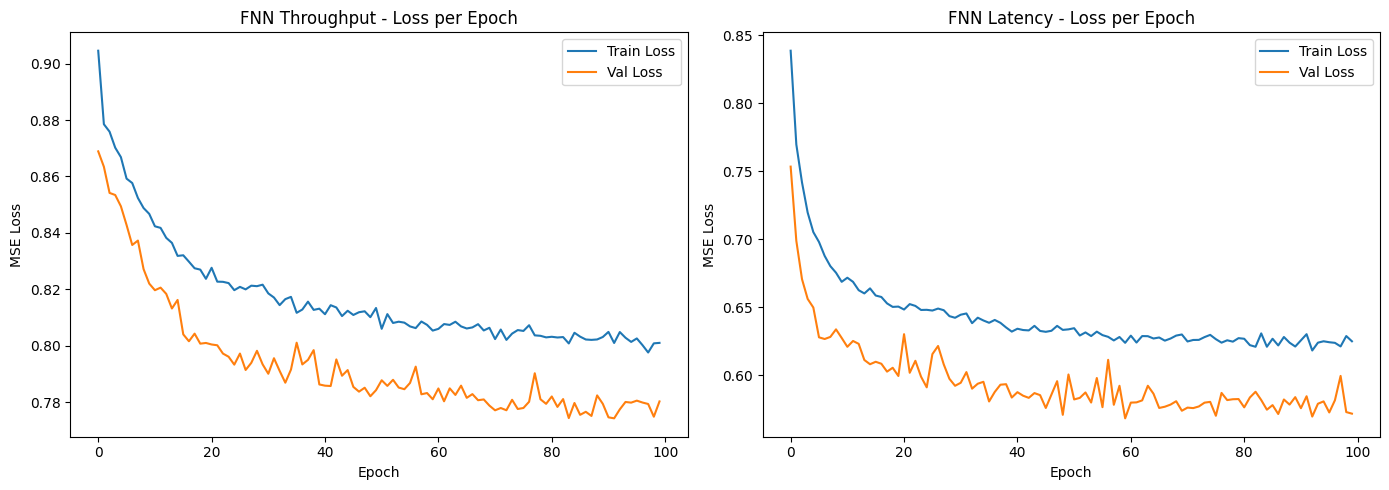

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses_t, label='Train Loss')
axes[0].plot(val_losses_t,   label='Val Loss')
axes[0].set_title('TxThroughput - Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].plot(train_losses_l, label='Train Loss')
axes[1].plot(val_losses_l,   label='Val Loss')
axes[1].set_title('AvgPingLatency - Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

These graphs show how our models learned by reducing the loss of both the training and validation datasets over 100 epochs. It seem that the latency model performs better than the throughput model because it achieves a lower loss value. Both models demonstrate excellent convergence, and the close alignment between their training and validation curves indicates strong generalization without overfitting. But we don't achiave a very low loss at the end of the model, so this can be emporved.

5. Evaluate your FNN: evaluate your solution using the test data and report the results.

In [ ]:
# Convert test data to tensors
X_test_tensor = torch.tensor(X_test_scaled.values, dtype=torch.float32)

#Predictions
model_throughput.eval()
model_latency.eval()

with torch.no_grad():
    y_pred_throughput = model_throughput(X_test_tensor).numpy()
    y_pred_latency    = model_latency(X_test_tensor).numpy()

# --- Inverse transform to get real values ---
y_pred_scaled     = np.hstack([y_pred_throughput, y_pred_latency])
y_pred_real       = scaler_y.inverse_transform(y_pred_scaled)

y_test_real       = scaler_y.inverse_transform(y_test_scaled)

In [ ]:
# Metrics
mse_throughput  = mean_squared_error(y_test_real[:, 0], y_pred_real[:, 0])

mse_latency     = mean_squared_error(y_test_real[:, 1], y_pred_real[:, 1])

print("TxThroughput:")
print(f"  MSE:  {mse_throughput:.4f}")

print("\nAvgPingLatency:")
print(f"  MSE:  {mse_latency:.4f}")

FNN Throughput (TxThroughput):
  MSE:  15.4495
  RMSE: 3.9306
  MAE:  3.0280

FNN Latency (AvgPingLatency):
  MSE:  46.1592
  RMSE: 6.7941
  MAE:  4.8378


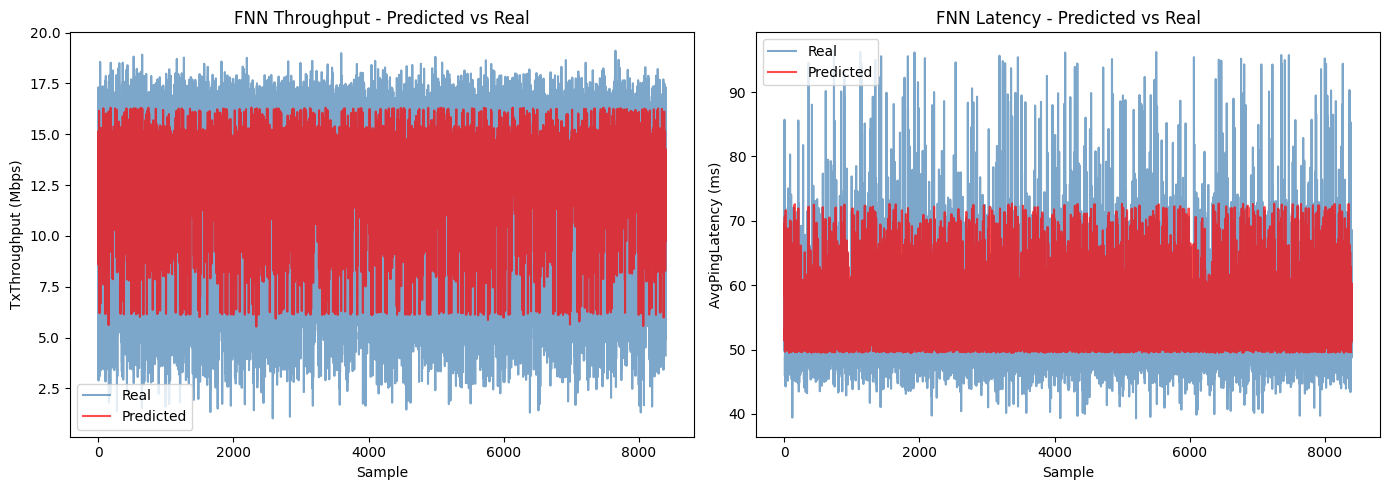

In [ ]:
# Predictions vs Real values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_axis = np.arange(len(y_test_real))

# Throughput
axes[0].plot(x_axis, y_test_real[:, 0], color='steelblue', alpha=0.7, label='Real')
axes[0].plot(x_axis, y_pred_real[:, 0], color='red',       alpha=0.7, label='Predicted')
axes[0].set_title('TxThroughput - Predicted vs Real')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('TxThroughput (Mbps)')
axes[0].legend()

# Latency
axes[1].plot(x_axis, y_test_real[:, 1], color='steelblue', alpha=0.7, label='Real')
axes[1].plot(x_axis, y_pred_real[:, 1], color='red',       alpha=0.7, label='Predicted')
axes[1].set_title('AvgPingLatency - Predicted vs Real')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('AvgPingLatency (ms)')
axes[1].legend()

plt.tight_layout()
plt.show()

From the graphs, we can see that our models do not perfectly approximate the dataset, as they struggle to reach extremely high or low values. The throughput model performs reasonably well, capturing a distribution shape similar to the original. On the other hand, the model predicting AvgPingLatency works well for high latency values, where the predictions tightly follow the ideal line. However, its performance decreases significantly for lower values, where the predictions become highly scattered.